<a href="https://colab.research.google.com/github/eudoalah-prog/Ass-2/blob/main/Ass_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

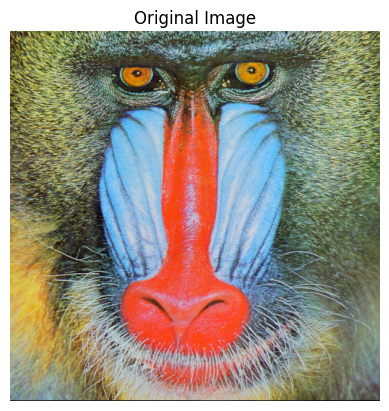

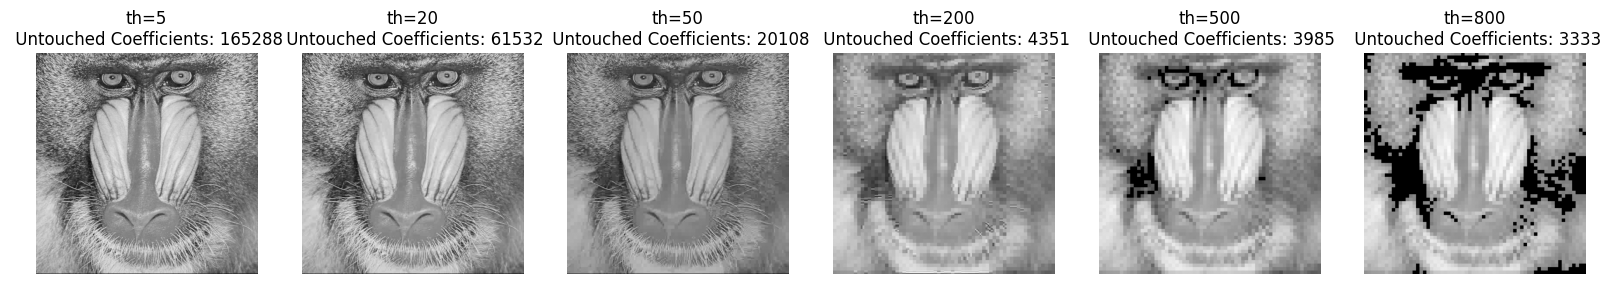

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct
from scipy.fftpack import idct

def prepare_image(path, space='YCrCb'):
    img_bgr = cv2.imread(path)
    if space.upper() == 'YCRCB':
        img_converted = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    elif space.upper() == 'LAB':
        img_converted = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    else:
        img_converted = img_bgr

    y_channel = img_converted[:, :, 0].astype(float)

    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')
    plt.show()
    return img_converted, y_channel

# DCT
def apply_dct8x8(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

# IDCT
def apply_idct8x8(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# Apply DCT, THRESHOLDING AND IDCT
def apply_dct_and_idct_to_image(y_channel, thereshold_value):
    h, w = y_channel.shape

    # print(h)
    # Padding
    pad_h = (8 - (h % 8)) % 8
    pad_w = (8 - (w % 8)) % 8
    new_h = h + pad_h
    new_w = w + pad_w
    padded = np.zeros((new_h, new_w))
    padded[:h, :w] = y_channel

    # Thresholding
    final = np.zeros((new_h, new_w),dtype=float)
    count = 0

    for i in range (0, new_h, 8):
        for j in range(0,new_w, 8):
            block = padded[i:i+8, j:j+8]
            # DCT
            dct_block = apply_dct8x8(block)

            # Thereshold
            threshold_block, threshold_count = threshold(dct_block, thereshold_value)
            count += threshold_count

            # IDCT
            idct_block = apply_idct8x8(threshold_block)

            final[i:i+8, j:j+8] = idct_block

    # Removing Padding
    final = final[:h, :w]

    return final, count

def threshold(block, th_value):
    aux = np.zeros_like(block)
    count = 0

    h,w = block.shape

    for i in range (h):
        for j in range (w):
            if(abs(block[i,j]) >= th_value):
                aux[i,j] = block[i,j]
                count += 1
            else:
                aux[i,j] = 0

    return aux, count

converted, y_channel = prepare_image('./images/baboon.png', 'YCrCb')

plt.figure(figsize=(20, 5))  # largura x altura

threshold_v = [5, 20, 50, 200, 500, 800]

for idx, th in enumerate(threshold_v):
    image_mod, retained = apply_dct_and_idct_to_image(y_channel, th)
    plt.subplot(1, len(threshold_v), idx + 1)
    plt.imshow(image_mod, cmap='gray')
    plt.title(f"th={th}\n Untouched Coefficients: {retained}")
    plt.axis('off')

# plt.suptitle("")
plt.show()




## 1.1

Neste ex comprimimos uma imagem usando DCT e depois vamos reconstruir a mesma imagem para ver se perde qualidade

Overall
1. Ler imagem
2. Converter para um espaço com brilho (Y + cor)
3. Dividir a imagem em blocos 8x8
4. Aplicar DCT (compressão no domínio da frequência)
5. Remover coeficientes pequenos (threshold)
6. Alpicar IDCT
7. Juntar tudo e mostrar imagem final

Começamos por ler uma imagem RGB, por dar display à imagem e converte-la para um espaço de cor do tipo YCrCb ou L*a*b, porque separamos brilho da cor e a compressão é feita principalmente no brilho. Isto acontece porque o olho humano é muito mais sensível ao brilho e menos sensível á cor, logo comprimimos a cor de forma mais intensificada.

De seguida, aplicamos DCT a cada bloco 8x8. DCT trasnforma o domiínio espacial, os pixeis, para domiínio de frequência.

Posteriormente, aplicamos o threshold para eliminar os coeficientes mais pequenos que o valor de threshold escolhido, com o objetivo de reduzir a informação -> compressão. Depois desta etapa, cada output vai ser uma matriz de 8x8, com valores de 0. Quanto maior o th, maior a compressão e pior a qualidade.

Por fim, aplicamos o IDCT que aplica a transformada inversa, formando uma imagem novo reaproveitando os blocos que foram reconstruídos nas etapas anteriores.

**1.2 Resultls and Subjective Evaluation (MOS)**

In this experiment, we tested the jpeg compression pipeline using the Discrete Cosine Transform (DCT) on the "baboon.png" image. By increasing the thresholld(th), we manualy controeld how many frequency coefficients were retained. The process invollved dividing the luminance (Y) channel into 8x8 blocks, applying padding where necessary and executing the fulll DCT - Threshodl - IDCT chain.

**Visual Results and Retained Coefficients.**

The figures generated in the script abover illustrate the trade off between the threshold value and the "recovered" signa quaity.

| Threshold ($th$) | Retained Coefficients | MOS Score (1-5) | Subjective Observation |
| :--- | :--- | :--- | :--- |
| **5** | High | **5** | Excellent; virtually indistinguishable from the original. |
| **20** | Medium-High | **4** | Good; very slight softening of the hair texture. |
| **50** | Medium | **4** | Good; minor artifacts in high-contrast areas. |
| **200** | Low | **3** | Fair; visible blocking artifacts (8x8 squares appear). |
| **500** | Very Low | **2** | Poor; significant loss of detail and heavy blockiness. |
| **800** | Minimal | **1** | Bad; the image structure is mostly lost. |



**Efficiency Anallysis by Image Content**

The efficiency of this compression method depends heavily on the spatiall frequency of the source image.

*   **Smooth image (low detail):** These are highly efficient in areas llike a celar sky, the DCT concentrates almost all energy into the DC coefficient (the top elft of the 8x8 block). we can use a high threshold and still get a MOS of 4 or 5 because there is very littlle detail to lose.



*  **Moderatey detaield image:** These show a standard compression curve. We retain a balanced number of coefficients to keep shapes while discarding noise.



*   **Highly detailed images:** These are the lelast efficient because the image contians many high frequency signals, the DCT spreads energy across many AC coefficients. Increasing the threshold causes immediate blocking artifacts, as the details that define the texture are discarded, elaving onlly the as the detaisl that define the texture are discarded, lelaving only the average color of each 8x8 bock.

**Conclusion**

The experiment confirms that JPEG pipeline is highly effective for data reduction, but its success relies on the Threshold(th) value. At higher thresholdl, we see a "quantization" effect where the human eye perceives the boundaries of the 8x8 blocks, signicantly owering the mean Opinion Score (MOS).















